# <ins>**MODELE XGboost**</ins>

In [39]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

[0]	train-auc:0.99928	train-logloss:0.59870	eval-auc:0.99930	eval-logloss:0.59868
[50]	train-auc:0.99983	train-logloss:0.00982	eval-auc:0.99986	eval-logloss:0.00991
[100]	train-auc:0.99985	train-logloss:0.00684	eval-auc:0.99987	eval-logloss:0.00675
[150]	train-auc:0.99985	train-logloss:0.00665	eval-auc:0.99987	eval-logloss:0.00653
[200]	train-auc:0.99986	train-logloss:0.00661	eval-auc:0.99986	eval-logloss:0.00650
[250]	train-auc:0.99986	train-logloss:0.00660	eval-auc:0.99986	eval-logloss:0.00649
[300]	train-auc:0.99986	train-logloss:0.00659	eval-auc:0.99986	eval-logloss:0.00647
[335]	train-auc:0.99986	train-logloss:0.00658	eval-auc:0.99986	eval-logloss:0.00647
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00   

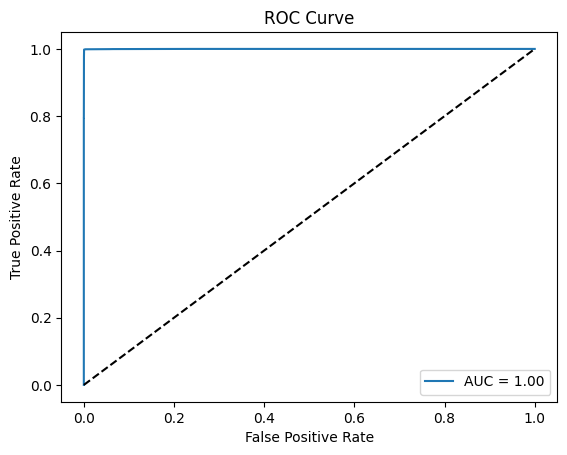

In [ ]:
# 1. Chargement et prétraitement initial
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)

    # Nettoyage des colonnes
    df = df.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))
    df['label'] = df['label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

    # Suppression des valeurs aberrantes extrêmes
    df = df[np.isfinite(df.select_dtypes(include=[np.number])).all(axis=1)]

    return df

df = load_and_preprocess('/home/antoine/NetworkAnomalyDetection/data/raw/bronze/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# 2. Feature Engineering (Source 1,5)
def feature_engineering(df):
    # Suppression des features constantes
    df = df.loc[:, df.nunique() > 1]

    # Séparation features/cible
    X = df.drop('label', axis=1)
    y = df['label']

    # Scaling robuste
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    # Sélection de features avec XGBoost (Source 1)
    selector = SelectFromModel(xgb.XGBClassifier(
        objective='binary:logistic',
        learning_rate=0.1,
        max_depth=4
    )).fit(X_scaled, y)

    return selector.transform(X_scaled), y

X, y = feature_engineering(df)

# 3. Split des données avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 4. Configuration XGBoost optimale (Source 1,2,4)
params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.1,
    'max_depth': 4,
    'subsample': 0.8,
    'scale_pos_weight': len(y_train[y_train==0])/len(y_train[y_train==1]),
    'eval_metric': ['auc', 'logloss']
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# 5. Entraînement avec early stopping (Source 2)
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds=50,
    verbose_eval=50
)

# 6. Évaluation détaillée
preds = model.predict(dtest)
y_pred = (preds > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
import os
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import logging
import seaborn as sns

class CICIDSEvaluator:
    def __init__(self, directory='/home/antoine/NetworkAnomalyDetection/data/raw/bronze', results_dir='results'):
        self.directory = directory
        self.results_dir = results_dir
        os.makedirs(results_dir, exist_ok=True)

        # Configuration XGBoost commune
        self.params = {
            'objective': 'binary:logistic',
            'eval_metric': ['auc', 'logloss'],
            'learning_rate': 0.1,
            'max_depth': 4,
            'subsample': 0.8,
            'early_stopping_rounds': 50
        }

        logging.basicConfig(
            filename=os.path.join(results_dir, 'evaluation.log'),
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s'
        )

    def _preprocess_data(self, df):
        """Nettoyage et préparation des données"""
        try:
            # Nettoyage des colonnes
            df.columns = (df.columns.str.strip()
                            .str.lower()
                            .str.replace('[^a-z0-9_]', '_', regex=True))

            # Encodage de la cible
            if 'label' in df.columns:
                # Mapping des labels
                condition1 = df['label']=='BENIGN'
                condition2 = df['label']!='BENIGN'
                df.loc[condition1, 'label'] = 0
                df.loc[condition2, 'label'] = 1
            else:
                raise ValueError("Colonne 'label' manquante dans le dataset")

            # Suppression des outliers astronomiques
            df = df.astype(float)
            df = df[np.isfinite(df).all(axis=1)]
            max_float32 = np.finfo(np.float32).max
            df = df[np.abs(df)<max_float32]

            df = df.dropna(axis=0, how='any')
            # Suppression des doublons réseau critiques
            df = df.drop_duplicates()

            y = df['label']
            X = df.drop('label', axis=1)
            # Normalisation
            self.scaler = MinMaxScaler()
            X_scaled = self.scaler.fit_transform(X)

            return X_scaled, y

        except Exception as e:
            logging.error(f"Erreur de prétraitement : {str(e)}")
            raise

    def _evaluate_model(self, model, X_test, y_test, filename):
        """Évaluation et enregistrement des résultats"""
        try:
            # Prédictions
            dtest = xgb.DMatrix(X_test)
            preds = model.predict(dtest)
            y_pred = (preds > 0.5).astype(int)

            # Métriques
            report = classification_report(y_test, y_pred)
            roc_auc = roc_auc_score(y_test, preds)

            # Matrice de confusion
            cm = confusion_matrix(y_test, y_pred)

            # Sauvegarde des résultats
            base_name = os.path.splitext(filename)[0]
            with open(os.path.join(self.results_dir, f'{base_name}_report.txt'), 'w') as f:
                f.write(f"ROC-AUC: {roc_auc:.4f}\n")
                f.write(report)
                f.write(f"\nMatrice de confusion:\n{cm}")

            # Visualisation
            self._plot_roc(y_test, preds, base_name)
            self._plot_confusion_matrix(cm, base_name)

            logging.info(f"Évaluation terminée pour {filename}")

        except Exception as e:
            logging.error(f"Erreur d'évaluation pour {filename} : {str(e)}")
            raise

    def _plot_roc(self, y_true, y_score, filename):
        """Génère la courbe ROC"""
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taux de faux positifs')
        plt.ylabel('Taux de vrais positifs')
        plt.title(f'Courbe ROC - {filename}')
        plt.legend()
        plt.savefig(os.path.join(self.results_dir, f'{filename}_roc.png'))
        plt.close()

    def _plot_confusion_matrix(self, cm, filename):
        """Visualise la matrice de confusion"""
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Matrice de confusion - {filename}')
        plt.xlabel('Prédit')
        plt.ylabel('Réel')
        plt.savefig(os.path.join(self.results_dir, f'{filename}_cm.png'))
        plt.close()

    def process_files(self):
        """Traite tous les fichiers du répertoire"""
        for filename in os.listdir(self.directory):
            if filename.endswith('.csv'):
                try:
                    logging.info(f"Traitement de {filename}...")
                    filepath = os.path.join(self.directory, filename)

                    # Chargement et prétraitement
                    df = pd.read_csv(filepath)
                    X, y = self._preprocess_data(df)

                    # Split des données
                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, stratify=y, random_state=42
                    )

                    # Entraînement XGBoost
                    dtrain = xgb.DMatrix(X_train, label=y_train)
                    dval = xgb.DMatrix(X_test, label=y_test)

                    self.params['scale_pos_weight'] = sum(y_train == 0) / sum(y_train == 1)

                    model = xgb.train(
                        self.params,
                        dtrain,
                        num_boost_round=1000,
                        evals=[(dtrain, 'train'), (dval, 'eval')],
                        verbose_eval=False
                    )

                    # Évaluation
                    self._evaluate_model(model, X_test, y_test, filename)

                except Exception as e:
                    logging.error(f"Échec du traitement pour {filename} : {str(e)}")
                    continue

# Utilisation
if __name__ == "__main__":
    evaluator = CICIDSEvaluator()
    evaluator.process_files()


INFO:root:Traitement de Wednesday-workingHours.pcap_ISCX.csv...
/home/antoine/miniconda3/envs/logs_project/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:32:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
INFO:root:Évaluation terminée pour Wednesday-workingHours.pcap_ISCX.csv
INFO:root:Traitement de Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
/home/antoine/miniconda3/envs/logs_project/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:33:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "early_stopping_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
INFO:root:Évaluation terminée pour Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
INFO:root:Traitement de Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
/home/antoine/miniconda3/envs/logs_project/lib/python3.12/site-packages/xgboost/training.py:18

### **2. Nettoyage du dataset**

In [21]:
def clean_column_network_data(df):
    """
    Nettoie les données réseau brutes du CICIDS2017

    Args:
        pd.DataFrame brute

    Returns:
        pd.DataFrame: DataFrame nettoyé et prêt pour l'analyse
    """
    # Configuration du logging
    logging.basicConfig(level=logging.INFO)

    try:
        # Nettoyage des noms de colonnes
        def clean_column_names(df):
            df.columns = (df.columns.str.strip()
                            .str.lower()
                            .str.replace('[^a-z0-9_]', '_', regex=True))
            return df
        df = clean_column_names(df)

        # Mapping des labels
        condition1 = df['label']=='BENIGN'
        condition2 = df['label']!='BENIGN'

        df.loc[condition1, 'label'] = 0
        df.loc[condition2, 'label'] = 1

        # Suppression des outliers astronomiques
        df = df.astype(float)
        df = df[np.isfinite(df).all(axis=1)]
        max_float32 = np.finfo(np.float32).max
        df = df[np.abs(df)<max_float32]

        # Suppression des lignes avec NaN après encodage et doublons
        initial_shape = df.shape[0]
        df = df.dropna(axis=0, how='any')
        # Suppression des doublons réseau critiques
        df = df.drop_duplicates()
        final_shape = df.shape[0]

        logging.info(f"Données nettoyées : {final_shape} lignes restantes ({initial_shape - final_shape} lignes supprimées)")

        return df

    except Exception as e:
        logging.error(f"Erreur lors du nettoyage : {str(e)}")
        raise

df = clean_column_network_data(df)

INFO:root:Données nettoyées : 223082 lignes restantes (2629 lignes supprimées)


In [22]:
df.head()

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,54865.0,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55054.0,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,55055.0,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,46236.0,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,54863.0,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# séparation des variables
y = df['label']
y = y.astype('int')
X = df.drop('label', axis = 1)

In [24]:
minmax = MinMaxScaler()
X = minmax.fit_transform(X)

In [25]:
X, X_valid, y, y_valid = train_test_split(X, y, test_size = 0.1)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

In [27]:
train = xgb.DMatrix(data = X_train, label=y_train)
test = xgb.DMatrix(data = X_test, label=y_test)
valid = xgb.DMatrix(data = X_valid, label=y_valid)

In [28]:
params = {'booster' : 'gbtree', 'learning_rate' : 1, 'objective' : 'binary:logistic'}

xbg1 = xgb.train(dtrain = train, params = params, num_boost_round = 100, early_stopping_rounds= 15, evals= [(train, 'train'), (test, 'eval')])


[0]	train-logloss:0.12304	eval-logloss:0.12309
[1]	train-logloss:0.04205	eval-logloss:0.04230
[2]	train-logloss:0.01553	eval-logloss:0.01584
[3]	train-logloss:0.00601	eval-logloss:0.00624
[4]	train-logloss:0.00241	eval-logloss:0.00265
[5]	train-logloss:0.00104	eval-logloss:0.00127
[6]	train-logloss:0.00053	eval-logloss:0.00068
[7]	train-logloss:0.00034	eval-logloss:0.00052
[8]	train-logloss:0.00025	eval-logloss:0.00040
[9]	train-logloss:0.00020	eval-logloss:0.00034
[10]	train-logloss:0.00017	eval-logloss:0.00034
[11]	train-logloss:0.00013	eval-logloss:0.00029
[12]	train-logloss:0.00012	eval-logloss:0.00029
[13]	train-logloss:0.00011	eval-logloss:0.00030
[14]	train-logloss:0.00010	eval-logloss:0.00029
[15]	train-logloss:0.00009	eval-logloss:0.00026
[16]	train-logloss:0.00009	eval-logloss:0.00025
[17]	train-logloss:0.00008	eval-logloss:0.00024
[18]	train-logloss:0.00008	eval-logloss:0.00025
[19]	train-logloss:0.00007	eval-logloss:0.00024
[20]	train-logloss:0.00007	eval-logloss:0.00025
[2

In [13]:

params2 = {'booster' : 'gbtree', 'learning_rate' : 0.01, 'objective' : 'binary:logistic'}
xbg2 = xgb.train(dtrain = train, params = params2, num_boost_round = 700, early_stopping_rounds= 15, evals= [(train, 'train'), (test, 'eval')])

[0]	train-logloss:0.67193	eval-logloss:0.67364
[1]	train-logloss:0.66221	eval-logloss:0.66389
[2]	train-logloss:0.65269	eval-logloss:0.65434
[3]	train-logloss:0.64337	eval-logloss:0.64498
[4]	train-logloss:0.63423	eval-logloss:0.63581
[5]	train-logloss:0.62527	eval-logloss:0.62682
[6]	train-logloss:0.61648	eval-logloss:0.61800
[7]	train-logloss:0.60787	eval-logloss:0.60936
[8]	train-logloss:0.59942	eval-logloss:0.60088
[9]	train-logloss:0.59113	eval-logloss:0.59257
[10]	train-logloss:0.58300	eval-logloss:0.58441
[11]	train-logloss:0.57502	eval-logloss:0.57640
[12]	train-logloss:0.56718	eval-logloss:0.56854
[13]	train-logloss:0.55949	eval-logloss:0.56083
[14]	train-logloss:0.55194	eval-logloss:0.55325
[15]	train-logloss:0.54453	eval-logloss:0.54581
[16]	train-logloss:0.53725	eval-logloss:0.53851
[17]	train-logloss:0.53009	eval-logloss:0.53133
[18]	train-logloss:0.52306	eval-logloss:0.52428
[19]	train-logloss:0.51616	eval-logloss:0.51735
[20]	train-logloss:0.50937	eval-logloss:0.51055
[2

In [29]:
preds1 = xbg1.predict(test)
xgbpreds1= pd.Series(
np.where(preds1 < 0.5, 0, 1))
pd.crosstab(xgbpreds1,pd.Series(y_test))

label,0,1
row_0,,
0,1744,1315
1,2272,1732


In [15]:
preds2 = xbg2.predict(test)
xgbpreds2= pd.Series(
np.where(preds2 < 0.5, 0, 1))
pd.crosstab(xgbpreds2,pd.Series(y_test))

label,0,1
row_0,,
0,1860,1322
1,2331,1723


In [16]:
xbg1.eval(valid)

'[0]\teval-logloss:0.00025453999968301'

In [17]:
xbg2.eval(valid)

'[0]\teval-logloss:0.00092298669941207'

### **4. Normalisation de X et séparation en jeu d'entrainement et de test**

In [57]:
minmax = MinMaxScaler()
X = minmax.fit_transform(X)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

### **5. Entrainement du modèle KNN sur le nouveau dataset constitué uniquement des variables retenues par SelectKBest.**

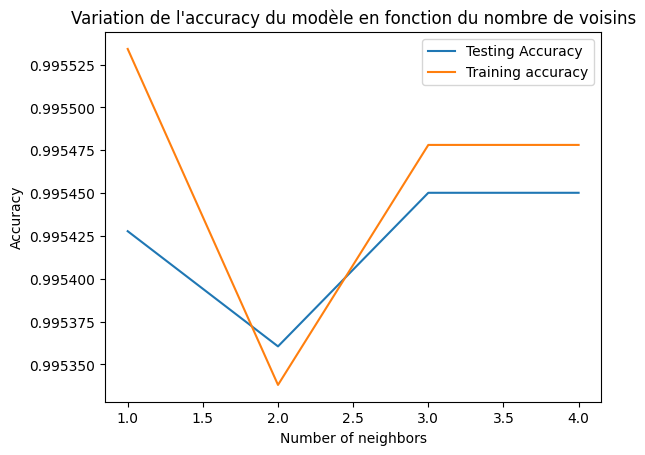

In [ ]:
from tensorflow.keras import layers, Model

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Sampling layer
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

# Decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(64, activation='relu')(decoder_input)
outputs = layers.Dense(input_dim, activation='sigmoid')(x)

# Modèles complets
encoder = Model(inputs, [z_mean, z_log_var, z])
decoder = Model(decoder_input, outputs)
vae_outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, vae_outputs)


In [ ]:
reconstruction_loss = tf.reduce_mean(
    tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(inputs, outputs),
        axis=1
    )
)
kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
total_loss = reconstruction_loss + kl_loss

vae.compile(optimizer='adam', loss=total_loss)


KNeighborsClassifier(algorithm='kd_tree', n_jobs=-1, n_neighbors=np.int64(3))

In [ ]:
history = vae.fit(
    X_train_normal,  # Uniquement données normales
    X_train_normal,
    epochs=100,
    batch_size=256,
    validation_split=0.15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10),
        ReduceLROnPlateau(factor=0.5, patience=5)
    ]
)


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18864
           1       0.99      1.00      1.00     25753

    accuracy                           1.00     44617
   macro avg       1.00      0.99      1.00     44617
weighted avg       1.00      1.00      1.00     44617



In [64]:
from sklearn.metrics import confusion_matrix, roc_auc_score, matthews_corrcoef, average_precision_score
print("Matrice de confusion:\n", confusion_matrix(y_test, knn_predicted_test_labels))
print("#"*50)
print("ROC-AUC SCORE:", roc_auc_score(y_test, knn_predicted_test_labels))
print("#"*50)
print("MCC Score:", matthews_corrcoef(y_test, knn_predicted_test_labels))
print("#"*50)
print("Precision-recall curve:", average_precision_score(y_test, knn_predicted_test_labels))

Matrice de confusion:
 [[18664   200]
 [    3 25750]]
##################################################
ROC-AUC SCORE: 0.9946406517293686
##################################################
MCC Score: 0.9907057060213805
##################################################
Precision-recall curve: 0.9922445163811686
